# **1. Setup & Libraries**

In [1]:
!pip install matplotlib-scalebar
!pip install contextily

# For post-hoc seasonal tests
!pip install scikit-posthocs

!pip install pymannkendall


In [2]:
!pip install torch torch-geometric torch-scatter torch-sparse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.3 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=664632 sha256=98850fb0a286248ab560f42cbb1d7d288f1b344f6f4f67c00a2e18dd738891dd
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1222874 sha256=a514f560124ea03f9a0b4bc2df26e12188dc830876e8d133409c392a01beb081
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built torch-scatte

In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


CUDA available: False
Number of GPUs: 0
Using CPU


In [4]:
import os
import glob
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns

from scipy.stats import mannwhitneyu, kruskal, wilcoxon
import pymannkendall as mk
import scikit_posthocs as sp


# **2. Load Dataset**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Data/Final processed 3-hourly rainfall data.csv"
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116614,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2116615,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2116616,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2116617,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


In [7]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069862,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2069863,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2069864,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2069865,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


# **3. EDA (quick checks)**

In [ ]:
df_rain.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2069867 entries, 0 to 2069866
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   StationID             int64  
 1   StationName           object 
 2   Latitude              float64
 3   Longitude             float64
 4   Primary_Region        object 
 5   Secondary_Region      object 
 6   Datetime              object 
 7   Year                  int64  
 8   Month                 int64  
 9   Day                   int64  
 10  Time                  int64  
 11  Season                object 
 12  DewPointTemperature   float64
 13  StationLevelPressure  float64
 14  SP                    float64
 15  DR                    float64
 16  Humidity              float64
 17  Rainfall              float64
dtypes: float64(8), int64(5), object(5)
memory usage: 284.3+ MB


In [ ]:
df_rain.describe()


,StationID,Latitude,Longitude,Year,Month,Day,Time,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
count,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06
mean,1.590622e+04,2.332243e+01,9.042684e+01,2.013025e+03,6.517799e+00,1.572708e+01,1.049884e+01,2.158189e+01,1.006446e+03,1.490370e+00,9.316562e+00,8.056917e+01,7.877763e-01
std,1.086843e+04,1.199083e+00,1.120197e+00,6.022836e+00,3.448572e+00,8.798788e+00,6.873358e+00,5.190200e+00,1.518150e+01,2.136396e+00,1.119727e+01,1.673008e+01,4.271327e+00
min,1.012000e+04,2.086670e+01,8.868330e+01,2.003000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.111100e+04,2.248330e+01,8.936670e+01,2.008000e+03,4.000000e+00,8.000000e+00,3.000000e+00,1.800000e+01,1.002200e+03,0.000000e+00,0.000000e+00,7.100000e+01,0.000000e+00
50%,1.170400e+04,2.316670e+01,9.033330e+01,2.013000e+03,7.000000e+00,1.600000e+01,9.000000e+00,2.400000e+01,1.006900e+03,0.000000e+00,0.000000e+00,8.600000e+01,0.000000e+00
75%,1.192900e+04,2.425000e+01,9.143330e+01,2.018000e+03,1.000000e+01,2.300000e+01,1.500000e+01,2.600000e+01,1.011300e+03,2.000000e+00,1.800000e+01,9.400000e+01,0.000000e+00
max,4.197700e+04,2.578330e+01,9.230000e+01,2.023000e+03,1.200000e+01,3.100000e+01,2.100000e+01,3.600000e+01,4.012300e+03,9.000000e+01,1.800000e+02,1.000000e+02,9.990000e+01


In [ ]:
df_rain["Datetime"] = pd.to_datetime(df_rain["Datetime"])
df_rain = df_rain.sort_values("Datetime")
print(df_rain["Datetime"].min(), " → ", df_rain["Datetime"].max())


2003-01-01 00:00:00  →  2023-12-31 21:00:00


In [ ]:
print("Stations:", df_rain["StationID"].nunique())
df_rain.groupby("StationID")["Rainfall"].count().describe()


Stations: 34


count       34.000000
mean     60878.441176
std       1050.853829
min      58424.000000
25%      61273.000000
50%      61360.000000
75%      61360.000000
max      61360.000000
Name: Rainfall, dtype: float64

In [ ]:
df_rain.isna().mean()


StationID               0.0
StationName             0.0
Latitude                0.0
Longitude               0.0
Primary_Region          0.0
Secondary_Region        0.0
Datetime                0.0
Year                    0.0
Month                   0.0
Day                     0.0
Time                    0.0
Season                  0.0
DewPointTemperature     0.0
StationLevelPressure    0.0
SP                      0.0
DR                      0.0
Humidity                0.0
Rainfall                0.0
dtype: float64

In [ ]:
df_rain["Rainfall"].isna().mean()


0.0

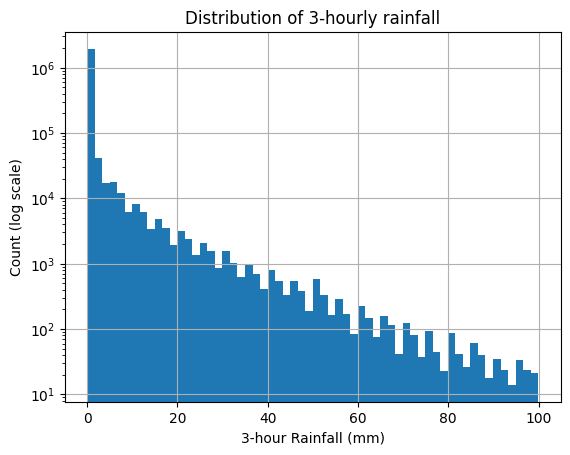

In [ ]:
import matplotlib.pyplot as plt

df_rain["Rainfall"].hist(bins=60, log=True)
plt.xlabel("3-hour Rainfall (mm)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of 3-hourly rainfall")
plt.show()


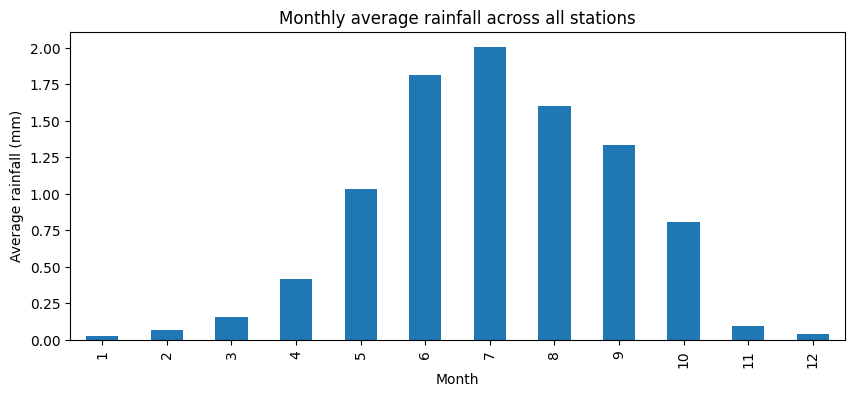

In [ ]:
monthly = df_rain.groupby("Month")["Rainfall"].mean()

monthly.plot(kind="bar", figsize=(10,4))
plt.ylabel("Average rainfall (mm)")
plt.title("Monthly average rainfall across all stations")
plt.show()


In [ ]:
threshold_95 = df_rain["Rainfall"].quantile(0.95)
threshold_99 = df_rain["Rainfall"].quantile(0.99)

threshold_95, threshold_99


(3.4, 21.0)

In [ ]:
gaps = (
    df_rain.sort_values("Datetime")
           .groupby("StationID")["Datetime"]
           .diff()
)

gaps_in_hours = gaps.dt.total_seconds() / 3600
gaps_in_hours.value_counts().head(10)


Datetime
3.0       2069584
6.0           237
24.0            8
7347.0          1
8763.0          1
723.0           1
747.0           1
Name: count, dtype: int64

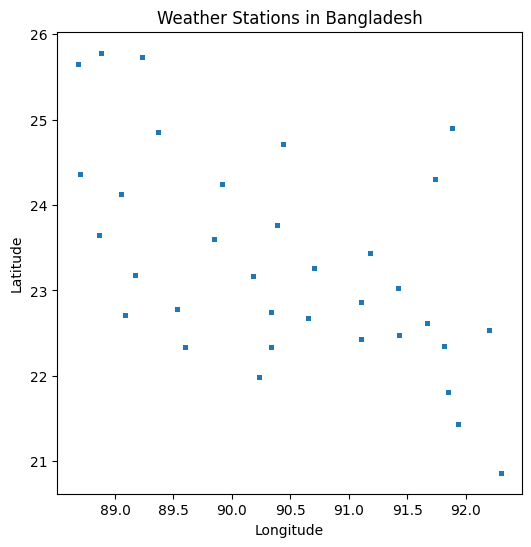

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df_rain["Longitude"], df_rain["Latitude"], s=5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Weather Stations in Bangladesh")
plt.show()


In [ ]:
station_mean = df_rain.groupby("StationID")["Rainfall"].mean()

station_mean.describe(), station_mean.sort_values().head(), station_mean.sort_values().tail()


(count    34.000000
 mean      0.789961
 std       0.257914
 min       0.434223
 25%       0.607140
 50%       0.697358
 75%       0.960748
 max       1.377476
 Name: Rainfall, dtype: float64,
 StationID
 10320    0.434223
 10910    0.473204
 41926    0.477689
 11505    0.537464
 10408    0.554707
 Name: Rainfall, dtype: float64,
 StationID
 11814    1.142311
 11927    1.177409
 11916    1.213818
 11929    1.374957
 10705    1.377476
 Name: Rainfall, dtype: float64)

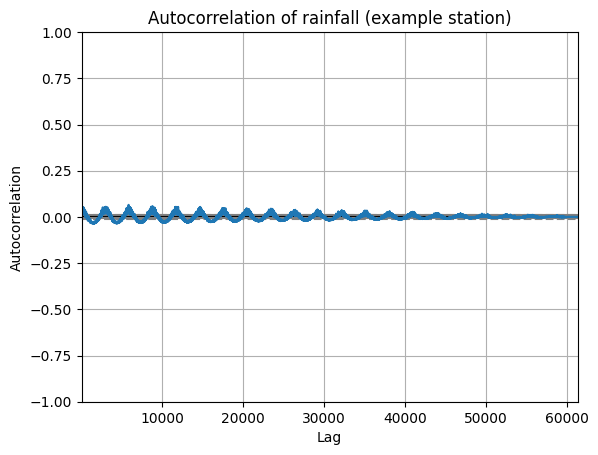

In [ ]:
example_station = df_rain["StationID"].iloc[0]
series = df_rain[df_rain["StationID"] == example_station]["Rainfall"]

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(series)
plt.title("Autocorrelation of rainfall (example station)")
plt.show()


In [ ]:
import numpy as np

is_heavy = df_rain["Rainfall"] >= 20  # example heavy threshold
run_length = np.diff(np.where(np.concatenate(([is_heavy.iloc[0]],
      is_heavy.to_numpy()[:-1] != is_heavy.to_numpy()[1:], [True]))))[::2]

run_length[:20]


array([[   2,  402,    1, ...,   27,    1, 6069]], dtype=int64)

In [ ]:
df_rain.groupby("Season")["Rainfall"].quantile(0.99)


Season
Monsoon         32.0
Post-Monsoon    13.8
Pre-Monsoon     17.0
Winter           0.4
Name: Rainfall, dtype: float64

In [ ]:
df_rain["Rainfall"].sort_values(ascending=False).head(10)


1038533    99.9
185574     99.8
1833540    99.8
1833092    99.4
1833093    99.4
1041784    99.2
1237462    99.2
122186     99.0
121371     99.0
865015     99.0
Name: Rainfall, dtype: float64

# **Hyperparameter Training**

In [ ]:
# ============================================================
# BanglaRain-ENS + Hyperparameter Tuning (Publication-ready style)
# Missingness-aware + Physics-aligned + Probabilistic
# Spatiotemporal Graph Transformer for 3h–24h rainfall + extreme risk
#
# ✅ DOES NOT change the ORIGINAL model structure
# ✅ Adds Hyperparameter Tuning (resume-safe + fixed-per-trial hp):
#    - fixed-per-trial hyperparams saved FIRST (trial_03 always same on rerun)
#    - resume-safe: skips trials that already have best_model.pt
#    - saves BEST checkpoint per trial + epoch logs
#    - writes tuning_summary.csv + best_trial.json
#
# ✅ UPDATED: Best-trial selection now considers BOTH:
#    - probabilistic rainfall forecasting (val CRPS_log)
#    - extreme-risk detection (mean Brier over flash/peak/acc)
#    via a normalized composite objective (default 0.5 / 0.5 weights)
#
# Objective (composite, lower is better):
#   composite_obj = 0.5*norm(CRPS_log) + 0.5*norm(mean_brier)
# ============================================================

import math
import random
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ✅ As original
set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 0.5) Mount Google Drive (Colab)
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving tuning results to:", SAVE_DIR)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (UNCHANGED)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Training / Evaluation
# ============================================================

def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, edge_index, optimizer, quantiles, weights, device):
    model.train()
    total = 0.0
    nb = 0

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # Quantile loss on log-rain
        q_losses = []
        for k, qv in enumerate(quantiles):
            q_losses.append(pinball_loss(q_hat[..., k], y_log, qv, mask=my))
        loss_q = torch.stack(q_losses).mean()

        # Risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # Crossing penalty (meaningful because we do NOT sort)
        q10 = q_hat[..., 0]
        q50 = q_hat[..., 1] if q_hat.size(-1) > 1 else q10
        q90 = q_hat[..., 2] if q_hat.size(-1) > 2 else q50
        phys_pen = (F.relu(q10 - q50) + F.relu(q50 - q90))
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1

    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Main runner (kept for final training later)
# ============================================================

def run_banglarain_ens(
    df_rain,
    k_nn=4,
    T_in=16,
    H_out=8,
    quantiles=(0.1, 0.5, 0.9),
    train_frac=0.7,
    val_frac=0.15,
    batch_size=32,
    lr=1e-3,
    epochs=20,
    d_model=96,
    seed=42,
    deterministic=False,
):
    set_seed(seed, deterministic=deterministic)

    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=k_nn)
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)
    print("edge_index:", edge_index.shape)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    print("Split:")
    print("  Train: 0 →", train_end)
    print("  Val:  ", train_end, "→", val_end)
    print("  Test: ", val_end, "→", T)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=T_in, H_out=H_out
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=T_in, H_out=H_out
    )
    ds_test = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=T_in, H_out=H_out
    )

    print("Dataset sizes:", len(ds_train), len(ds_val), len(ds_test))

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]
    print("Input feature dim:", F_in)

    # pos_weight from TRAIN only
    flash_all, mflash_all = [], []
    peak_all,  mpeak_all  = [], []
    acc_all,   macc_all   = [], []

    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash)
        mflash_all.append(mflash)
        peak_all.append(peak)
        mpeak_all.append(mpeak)
        acc_all.append(acc)
        macc_all.append(macc)

    flash_all = torch.cat(flash_all, dim=0)
    mflash_all = torch.cat(mflash_all, dim=0)
    peak_all = torch.cat(peak_all, dim=0)
    mpeak_all = torch.cat(mpeak_all, dim=0)
    acc_all = torch.cat(acc_all, dim=0)
    macc_all = torch.cat(macc_all, dim=0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    print("pos_weight flash:", float(pos_w_flash))
    print("pos_weight peak :", float(pos_w_peak))
    print("pos_weight acc  :", float(pos_w_acc))

    model = BanglaRainENS(
        num_stations=N,
        in_features=F_in,
        T_in=T_in,
        H_out=H_out,
        num_seasons=len(prep["unique_seasons"]),
        quantiles=quantiles,
        d_model=d_model,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    weights = {
        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak":  2.0,
        "lambda_acc":   2.0,
        "lambda_phys":  0.2,
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = math.inf
    best_state = None

    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, edge_index, optimizer, quantiles, weights, device)
        val_scores = evaluate(model, val_loader, edge_index, quantiles, device)

        val_key = val_scores["CRPS_log"]
        improved = val_key < best_val
        if improved:
            best_val = val_key
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {ep:02d} | train_loss={tr_loss:.4f} | "
            f"val_CRPS(log)={val_scores['CRPS_log']:.4f} | "
            f"val_CRPS(mm)={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f} | "
            f"{'BEST' if improved else ''}"
        )

        fm = val_scores["Flash_metrics"]
        if fm["pr_auc"] == fm["pr_auc"]:
            print(f"   Val Flash PR-AUC: {fm['pr_auc']:.4f} (n_valid={fm['n_valid']})")

    if best_state is not None:
        model.load_state_dict(best_state)
        print("Loaded best model by val CRPS(log):", best_val)

    test_scores = evaluate(model, test_loader, edge_index, quantiles, device)
    return model, prep, scaler, (thr3h, thrAcc24), test_scores


# ============================================================
# 8.5) Hyperparameter Tuning (does NOT modify model structure)
# ============================================================

def build_model_and_optimizer_from_hp(hp, N, F_in, num_seasons):
    model = BanglaRainENS(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=num_seasons,
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        n_heads=hp["n_heads"],
        num_temporal_layers=hp["num_temporal_layers"],
        num_gat_layers=hp["num_gat_layers"],
        gat_heads=hp["gat_heads"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )
    return model, optimizer


def sample_hparams(rng):
    H_out = 8  # fixed for 24h = 8×3h

    d_model = int(rng.choice([64, 128]))
    n_heads_candidates = [h for h in [2, 4, 8] if d_model % h == 0]
    n_heads = int(rng.choice(n_heads_candidates))

    hp = {
        "k_nn": int(rng.choice([3, 4, 5, 6, 7])),
        "T_in": int(rng.choice([16, 24, 32])),
        "H_out": H_out,

        "d_model": d_model,
        "dropout": float(rng.choice([0.1, 0.2, 0.3])),

        "n_heads": n_heads,
        "num_temporal_layers": int(rng.choice([1, 2])),  # CPU-safe
        "num_gat_layers": int(rng.choice([1, 2])),       # CPU-safe
        "gat_heads": int(rng.choice([1, 2])),            # CPU-safe

        "lr": float(rng.choice([5e-4, 1e-3, 2e-3])),
        "weight_decay": float(rng.choice([1e-5, 1e-4])),

        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak": 2.0,
        "lambda_acc": 2.0,
        "lambda_phys": float(rng.choice([0.0, 0.1, 0.25])),

        "batch_size": int(rng.choice([8, 16])),  # CPU-safe
        "epochs": 10,

        "quantiles": (0.1, 0.5, 0.9),
    }

    # CPU time safety (optional): avoid the heaviest combo
    if hp["T_in"] == 32 and hp["d_model"] == 128:
        hp["batch_size"] = 8

    return hp


def run_one_trial(df_rain, trial_id, hp, trial_dir, base_seed=42):
    # reproducibility per trial
    set_seed(base_seed + trial_id, deterministic=False)

    # Prepare data objects for this trial (depends on k_nn, T_in, H_out)
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=hp["k_nn"])
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=hp["batch_size"], shuffle=False)

    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]

    # pos weights from TRAIN only
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model, optimizer = build_model_and_optimizer_from_hp(
        hp, N=N, F_in=F_in, num_seasons=len(prep["unique_seasons"])
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None  # ✅ store metrics at best CRPS epoch
    trial_log = []

    for ep in range(1, hp["epochs"] + 1):
        tr_loss = train_one_epoch(
            model, train_loader, edge_index, optimizer,
            quantiles=hp["quantiles"], weights=weights, device=device
        )
        val_scores = evaluate(
            model, val_loader, edge_index,
            quantiles=hp["quantiles"], device=device
        )

        val_key = float(val_scores["CRPS_log"])
        trial_log.append({
            "trial": trial_id,
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        })

        print(f"[Trial {trial_id:02d}] Epoch {ep:02d} | train={tr_loss:.4f} | val_CRPS_log={val_key:.4f}")

        if val_key < best_val:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Save trial artifacts
    ckpt_path = os.path.join(trial_dir, "best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,  # ✅ includes Brier at best epoch
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
    }, ckpt_path)

    pd.DataFrame(trial_log).to_csv(os.path.join(trial_dir, "epoch_log.csv"), index=False)

    # Return best-epoch metrics for global selection
    return {
        "trial": int(trial_id),
        "best_val_CRPS_log": float(best_val),
        "best_epoch": int(best_epoch),
        "ckpt_path": ckpt_path,
        "val_Brier_flash": float(best_metrics["Brier_flash"]) if best_metrics is not None else np.nan,
        "val_Brier_peak":  float(best_metrics["Brier_peak"])  if best_metrics is not None else np.nan,
        "val_Brier_acc":   float(best_metrics["Brier_acc"])   if best_metrics is not None else np.nan,
        **hp
    }


def tune_banglarain(df_rain, n_trials=10, base_seed=42):
    rng = np.random.RandomState(base_seed)

    summary_path = os.path.join(SAVE_DIR, "tuning_summary.csv")
    all_results = []

    # Resume summary if exists
    if os.path.exists(summary_path):
        try:
            existing = pd.read_csv(summary_path)
            if len(existing) > 0 and "trial" in existing.columns:
                all_results = existing.to_dict("records")
                print(f"✅ Found existing tuning_summary.csv with {len(existing)} rows (resume mode).")
        except Exception as e:
            print("⚠️ Could not load existing tuning_summary.csv. Starting fresh.", str(e))

    for t in range(n_trials):
        trial_dir = os.path.join(SAVE_DIR, f"trial_{t:02d}")
        os.makedirs(trial_dir, exist_ok=True)

        hp_path = os.path.join(trial_dir, "hparams.json")
        ckpt_path = os.path.join(trial_dir, "best_model.pt")

        # Skip completed trials
        if os.path.exists(ckpt_path):
            print(f"[Trial {t:02d}] ✅ best_model.pt exists -> skipping.")
            continue

        # Fixed-per-trial hp: reuse if exists, else sample and SAVE FIRST
        if os.path.exists(hp_path):
            with open(hp_path, "r") as f:
                hp = json.load(f)
            print(f"\n[Trial {t:02d}] ✅ Reusing saved hyperparameters: {hp_path}")
        else:
            hp = sample_hparams(rng)
            with open(hp_path, "w") as f:
                json.dump(hp, f, indent=2)
            print(f"\n[Trial {t:02d}] 💾 Sampled+saved hyperparameters: {hp_path}")

        print("\n" + "="*80)
        print(f"Starting Trial {t:02d} with hparams:")
        print(hp)
        print("="*80)

        try:
            res = run_one_trial(df_rain, trial_id=t, hp=hp, trial_dir=trial_dir, base_seed=base_seed)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[Trial {t:02d}] CUDA OOM. Skipping trial (hp kept).")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

        all_results.append(res)
        pd.DataFrame(all_results).to_csv(summary_path, index=False)

    # Load final summary (whatever exists now)
    if os.path.exists(summary_path):
        results_df = pd.read_csv(summary_path)
    else:
        results_df = pd.DataFrame(all_results)

    if len(results_df) == 0:
        raise RuntimeError("No successful trials completed.")

    # ============================================================
    # ✅ UPDATED BEST TRIAL SELECTION (CRPS + Risk Brier)
    # ============================================================
    eps = 1e-12

    has_brier_cols = all(
        c in results_df.columns for c in ["val_Brier_flash", "val_Brier_peak", "val_Brier_acc"]
    )

    if has_brier_cols:
        results_df["mean_brier"] = (
            results_df["val_Brier_flash"].astype(float) +
            results_df["val_Brier_peak"].astype(float) +
            results_df["val_Brier_acc"].astype(float)
        ) / 3.0

        crps = results_df["best_val_CRPS_log"].astype(float)
        bri  = results_df["mean_brier"].astype(float)

        crps_n = (crps - crps.min()) / (crps.max() - crps.min() + eps)
        bri_n  = (bri  - bri.min())  / (bri.max()  - bri.min()  + eps)

        w_crps = 0.5
        w_risk = 0.5
        results_df["composite_obj"] = w_crps * crps_n + w_risk * bri_n

        # Sort by composite objective
        results_df = results_df.sort_values("composite_obj", ascending=True)
    else:
        print("⚠️ Brier columns not found in summary; selecting best trial by best_val_CRPS_log only.")
        results_df = results_df.sort_values("best_val_CRPS_log", ascending=True)

    # Save ranked summary
    results_df.to_csv(summary_path, index=False)

    best = results_df.iloc[0].to_dict()
    with open(os.path.join(SAVE_DIR, "best_trial.json"), "w") as f:
        json.dump(best, f, indent=2)

    print("\n✅ Tuning finished.")
    print("Best trial:", int(best["trial"]))
    if "composite_obj" in best:
        print("Best composite objective:", best["composite_obj"])
    print("Best val CRPS_log:", best["best_val_CRPS_log"])
    if "mean_brier" in best:
        print("Best mean Brier (flash/peak/acc):", best["mean_brier"])
    print("Checkpoint:", best["ckpt_path"])

    return results_df, best


# ============================================================
# 9) Run
# ============================================================

# (1) Hyperparameter tuning:
# results_df, best_trial = tune_banglarain(df_rain, n_trials=10, base_seed=42)

# (2) Final training (optional): after tuning, plug best_trial params into run_banglarain_ens
# model, prep, scaler, thresholds, test_scores = run_banglarain_ens(
#     df_rain,
#     k_nn=int(best_trial["k_nn"]),
#     T_in=int(best_trial["T_in"]),
#     H_out=int(best_trial["H_out"]),
#     quantiles=tuple(best_trial["quantiles"]),
#     batch_size=int(best_trial["batch_size"]),
#     lr=float(best_trial["lr"]),
#     epochs=20,              # you can increase for final run
#     d_model=int(best_trial["d_model"]),
#     seed=42,
#     deterministic=False,
# )


Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving tuning results to: /content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1


In [ ]:
results_df, best_trial = tune_banglarain(df_rain, n_trials=15, base_seed=42)


✅ Found existing tuning_summary.csv with 13 rows (resume mode).
[Trial 00] ✅ best_model.pt exists -> skipping.
[Trial 01] ✅ best_model.pt exists -> skipping.
[Trial 02] ✅ best_model.pt exists -> skipping.
[Trial 03] ✅ best_model.pt exists -> skipping.
[Trial 04] ✅ best_model.pt exists -> skipping.
[Trial 05] ✅ best_model.pt exists -> skipping.
[Trial 06] ✅ best_model.pt exists -> skipping.
[Trial 07] ✅ best_model.pt exists -> skipping.
[Trial 08] ✅ best_model.pt exists -> skipping.
[Trial 09] ✅ best_model.pt exists -> skipping.
[Trial 10] ✅ best_model.pt exists -> skipping.
[Trial 11] ✅ best_model.pt exists -> skipping.
[Trial 12] ✅ best_model.pt exists -> skipping.

[Trial 13] ✅ Reusing saved hyperparameters: /content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1/trial_13/hparams.json

Starting Trial 13 with hparams:
{'k_nn': 3, 'T_in': 32, 'H_out': 8, 'd_model': 64, 'dropout': 0.3, 'n_heads': 2, 'num_temporal_layers': 1, 'num_gat_layers': 2, 'gat_heads': 2, 'lr': 0.002, 'wei

/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 13] Epoch 01 | train=4.8334 | val_CRPS_log=0.1465


/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 13] Epoch 02 | train=4.6799 | val_CRPS_log=0.1415


...

[Trial 14] Epoch 08 | train=4.3972 | val_CRPS_log=0.1381


/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 09 | train=4.3853 | val_CRPS_log=0.1429


/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 10 | train=4.3765 | val_CRPS_log=0.1393

✅ Tuning finished.
Best trial: 4
Best composite objective: 0.05589926324180735
Best val CRPS_log: 0.1354140129535806
Best mean Brier (flash/peak/acc): 0.136490625333202
Checkpoint: /content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1/trial_04/best_model.pt


# Training code

In [ ]:
# ============================================================
# BanglaRain-ENS: Final Training Script (Standalone)
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes best_trial.json exists (from previous tuning) at:
#     SAVE_DIR/best_trial.json
# - Loads best hyperparameters
# - Trains final model with:
#     * early stopping on val CRPS_log
#     * per-epoch metrics printed + logged
# - Saves to Google Drive:
#     * final_epoch_log.csv
#     * final_best_model.pt
# ============================================================

import math
import random
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Path where tuning saved best_trial.json
SAVE_DIR = r"C:\Users\U\Documents\Rainfall\BanglaRainENS\Tuning_Results\v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Tuning results directory:", SAVE_DIR)

# Path where final model + logs will be saved
FINAL_SAVE_DIR = r"C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)
print("Final run artifacts will be saved to:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }

# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler

# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]          # still used for labels & masks
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)

        # 🔸 NO missingness features in the input:
        x_all = np.concatenate([x, tf], axis=-1)


        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )

# ============================================================
# 6) Model
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 7) Training / Evaluation
# ============================================================

def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, edge_index, optimizer, quantiles, weights, device):
    model.train()
    total = 0.0
    nb = 0

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # Quantile loss on log-rain
        q_losses = []
        for k, qv in enumerate(quantiles):
            q_losses.append(pinball_loss(q_hat[..., k], y_log, qv, mask=my))
        loss_q = torch.stack(q_losses).mean()

        # Risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # Crossing penalty (meaningful because we do NOT sort)
        q10 = q_hat[..., 0]
        q50 = q_hat[..., 1] if q_hat.size(-1) > 1 else q10
        q90 = q_hat[..., 2] if q_hat.size(-1) > 2 else q50
        phys_pen = (F.relu(q10 - q50) + F.relu(q50 - q90))
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1

    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 8) Hyperparams loader (from best_trial.json)
# ============================================================

def load_best_hparams(best_trial_path):
    """
    Load best_trial.json and build a clean hp dict with proper dtypes.
    Ignores any stored 'quantiles' and fixes to (0.1, 0.5, 0.9).
    """
    with open(best_trial_path, "r") as f:
        best = json.load(f)

    hp = {
        "k_nn": int(best["k_nn"]),
        "T_in": int(best["T_in"]),
        "H_out": int(best["H_out"]),
        "d_model": int(best["d_model"]),
        "dropout": float(best["dropout"]),
        "n_heads": int(best["n_heads"]),
        "num_temporal_layers": int(best["num_temporal_layers"]),
        "num_gat_layers": int(best["num_gat_layers"]),
        "gat_heads": int(best["gat_heads"]),
        "lr": float(best["lr"]),
        "weight_decay": float(best["weight_decay"]),
        "lambda_q": float(best.get("lambda_q", 1.0)),
        "lambda_flash": float(best.get("lambda_flash", 2.0)),
        "lambda_peak": float(best.get("lambda_peak", 2.0)),
        "lambda_acc": float(best.get("lambda_acc", 2.0)),
        "lambda_phys": float(best.get("lambda_phys", 0.1)),
        "batch_size": int(best["batch_size"]),
        # epochs is max epochs; can override
        "epochs": int(best.get("epochs", 10)),
        "quantiles": (0.1, 0.5, 0.9),
    }
    return hp

# ============================================================
# 9) Final training with early stopping
# ============================================================

def final_train_banglarain(df_rain,
                           hp,
                           final_save_dir=FINAL_SAVE_DIR,
                           train_frac=0.7,
                           val_frac=0.15,
                           base_seed=42,
                           max_epochs=None,
                           patience=5):
    """
    Final training run with fixed hyperparameters (hp).
    - Uses same preprocessing as tuning.
    - Early stopping on val CRPS_log with given patience.
    - Saves:
        * final_best_model.pt  (state_dict + scaler + thresholds + meta)
        * final_epoch_log.csv  (epoch-wise metrics)
    """
    if max_epochs is None:
        max_epochs = hp["epochs"]

    # Reproducibility
    set_seed(base_seed, deterministic=False)

    # 1) Preprocessing
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=hp["k_nn"])
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=hp["batch_size"], shuffle=False)

    # Infer input feature dim
    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]

    # 2) Pos-weights from training data
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    # 3) Build model + optimizer from hp
    model = BanglaRainENS(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=len(prep["unique_seasons"]),
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        n_heads=hp["n_heads"],
        num_temporal_layers=hp["num_temporal_layers"],
        num_gat_layers=hp["num_gat_layers"],
        gat_heads=hp["gat_heads"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    # 4) Training loop with early stopping
    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    epoch_log = []
    epochs_since_improve = 0

    for ep in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(
            model, train_loader, edge_index, optimizer,
            quantiles=hp["quantiles"], weights=weights, device=device
        )
        val_scores = evaluate(
            model, val_loader, edge_index,
            quantiles=hp["quantiles"], device=device
        )

        val_key = float(val_scores["CRPS_log"])

        # Flatten some event metrics for logging
        fm = val_scores["Flash_metrics"]
        pm = val_scores["Peak24_metrics"]
        am = val_scores["Acc24_metrics"]

        row = {
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
            "flash_pr_auc": float(fm.get("pr_auc", np.nan)),
            "flash_roc_auc": float(fm.get("roc_auc", np.nan)),
            "peak_pr_auc": float(pm.get("pr_auc", np.nan)),
            "peak_roc_auc": float(pm.get("roc_auc", np.nan)),
            "acc_pr_auc": float(am.get("pr_auc", np.nan)),
            "acc_roc_auc": float(am.get("roc_auc", np.nan)),
            "flash_n_valid": int(fm.get("n_valid", 0)),
            "peak_n_valid": int(pm.get("n_valid", 0)),
            "acc_n_valid": int(am.get("n_valid", 0)),
        }
        epoch_log.append(row)

        print(
            f"[FINAL] Epoch {ep:02d} | "
            f"train={tr_loss:.4f} | "
            f"val_CRPS_log={val_key:.4f} | "
            f"val_CRPS_mm={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f}"
        )

        # Check improvement
        if val_key < best_val - 1e-6:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
            improved = True
        else:
            epochs_since_improve += 1
            improved = False

        if improved:
            print(f"   -> New best epoch {ep:02d} (val_CRPS_log={best_val:.4f})")
        else:
            print(f"   -> No improvement for {epochs_since_improve} epoch(s)")

        # Save epoch log after each epoch (safe vs Colab disconnects)
        log_path = os.path.join(final_save_dir, "final_epoch_log.csv")
        pd.DataFrame(epoch_log).to_csv(log_path, index=False)

        # Early stopping check
        if epochs_since_improve >= patience:
            print(f"\n[EARLY STOP] No improvement in {patience} epochs. Stopping at epoch {ep}.")
            break

    # 5) Save best model checkpoint for reuse
    ckpt_path = os.path.join(final_save_dir, "final_best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
        "thr3h": thr3h,
        "thrAcc24": thrAcc24,
        "stations": prep["stations"],
        "times": prep["times"],
    }, ckpt_path)

    print("\n[FINAL] Training finished.")
    print("Best epoch:", best_epoch, "| best val CRPS_log:", best_val)
    print("Checkpoint saved to:", ckpt_path)
    print("Epoch log saved to:", log_path)

    return {
        "best_epoch": best_epoch,
        "best_val_CRPS_log": best_val,
        "ckpt_path": ckpt_path,
        "log_path": log_path,
        "hp": hp,
    }

# ============================================================
# 10) Run final training (example)
# ============================================================

# Assumes df_rain (your big 3-hourly DataFrame) is already in memory.
# Assumes best_trial.json exists in SAVE_DIR from your previous tuning.

best_trial_path = os.path.join(SAVE_DIR, "best_trial.json")
best_hp = load_best_hparams(best_trial_path)

# Optionally override max epochs for final run
best_hp["epochs"] = 50  # e.g., 30 epochs max

final_results = final_train_banglarain(
    df_rain=df_rain,
    hp=best_hp,
    final_save_dir=FINAL_SAVE_DIR,
    train_frac=0.7,
    val_frac=0.15,
    base_seed=42,
    max_epochs=best_hp["epochs"],
    patience=10,   # early stopping patience
)

print("\nFinal results summary:")
print(final_results)


Using device: cpu
Tuning results directory: C:\Users\U\Documents\Rainfall\BanglaRainENS\Tuning_Results\v1
Final run artifacts will be saved to: C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1
Total stations: 34
Total unique times: 61360


C:\Users\U\AppData\Local\Temp\ipykernel_14340\1988637782.py:415: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 01 | train=4.6291 | val_CRPS_log=0.1403 | val_CRPS_mm=0.7108 | val_BS_flash=0.1566 | val_BS_peak=0.1699 | val_BS_acc=0.1663
   -> New best epoch 01 (val_CRPS_log=0.1403)


C:\Users\U\AppData\Local\Temp\ipykernel_14340\1988637782.py:415: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 02 | train=4.4195 | val_CRPS_log=0.1373 | val_CRPS_mm=0.7086 | val_BS_flash=0.1379 | val_BS_peak=0.1513 | val_BS_acc=0.1521
   -> New best epoch 02 (val_CRPS_log=0.1373)


...

[FINAL] Epoch 19 | train=4.0434 | val_CRPS_log=0.1364 | val_CRPS_mm=0.7052 | val_BS_flash=0.1186 | val_BS_peak=0.1505 | val_BS_acc=0.1333
   -> No improvement for 8 epoch(s)


C:\Users\U\AppData\Local\Temp\ipykernel_14340\1988637782.py:415: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 20 | train=4.0253 | val_CRPS_log=0.1360 | val_CRPS_mm=0.6998 | val_BS_flash=0.1019 | val_BS_peak=0.1413 | val_BS_acc=0.1078
   -> No improvement for 9 epoch(s)


C:\Users\U\AppData\Local\Temp\ipykernel_14340\1988637782.py:415: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 21 | train=4.0159 | val_CRPS_log=0.1356 | val_CRPS_mm=0.6996 | val_BS_flash=0.1197 | val_BS_peak=0.1521 | val_BS_acc=0.1381
   -> No improvement for 10 epoch(s)

[EARLY STOP] No improvement in 10 epochs. Stopping at epoch 21.

[FINAL] Training finished.
Best epoch: 11 | best val CRPS_log: 0.13505505377634425
Checkpoint saved to: C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1\final_best_model.pt
Epoch log saved to: C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1\final_epoch_log.csv

Final results summary:
{'best_epoch': 11, 'best_val_CRPS_log': 0.13505505377634425, 'ckpt_path': 'C:\\Users\\U\\Documents\\Rainfall\\BanglaRainENS\\Final_Run_no_missing\\v1\\final_best_model.pt', 'log_path': 'C:\\Users\\U\\Documents\\Rainfall\\BanglaRainENS\\Final_Run_no_missing\\v1\\final_epoch_log.csv', 'hp': {'k_nn': 7, 'T_in': 24, 'H_out': 8, 'd_model': 64, 'dropout': 0.2, 'n_heads': 8, 'num_temporal_layers': 2, 'num_gat_layers': 2, 'gat_heads': 2, '

# Testing

Using device: cpu
Checkpoint path: C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1\final_best_model.pt
Log path       : C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1\final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1351
  best_epoch       : 11
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 11

Model rebuilt and weights loaded.


C:\Users\U\AppData\Local\Temp\ipykernel_14340\1725414254.py:408: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



========== TEST METRICS ==========
CRPS_log   : 0.1146
CRPS_mm    : 0.5975
Brier_flash: 0.1179
Brier_peak : 0.1372
Brier_acc  : 0.1218

[Flash 3h]  PR-AUC=0.4111, ROC-AUC=0.9218, n_valid=307231
[Peak24]   PR-AUC=0.6223, ROC-AUC=0.8837, n_valid=307263
[Acc24]    PR-AUC=0.2676, ROC-AUC=0.8829, n_valid=306923

Loaded epoch log with 21 rows.


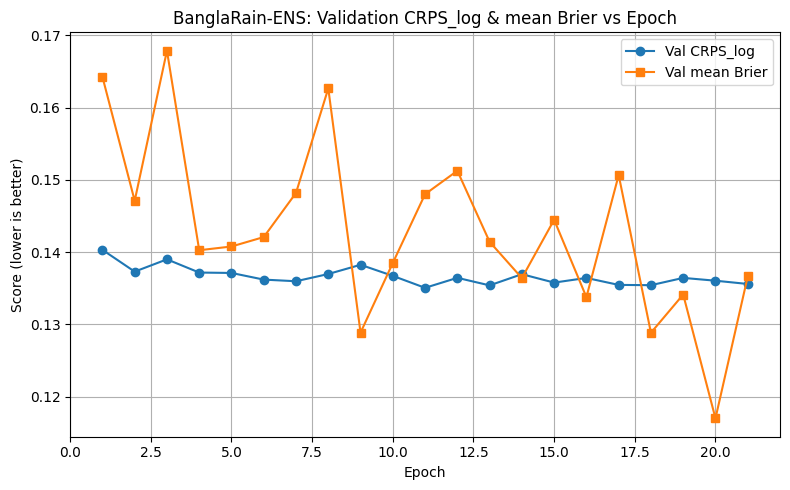

In [ ]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class
#    - model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (SAME STRUCTURE AS TUNING/TRAINING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================

FINAL_SAVE_DIR = r"C:\Users\U\Documents\Rainfall\BanglaRainENS\Final_Run_no_missing\v1"
CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
# ckpt = torch.load(CKPT_PATH, map_location=device)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

hp = ckpt["hparams"]            # dict of best hyperparameters
state_dict = ckpt["state_dict"] # model weights

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")

# ---- 8.2 df_rain MUST BE LOADED HERE ----
# Example:
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")
# Make sure it is exactly the same dataset used in training.

# >>> UNCOMMENT AND SET YOUR PATH <<<
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")

# ---- 8.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# Train-only scaling (same as training)
X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

# Thresholds from TRAIN
thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

# Acc24 + thresholds
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))
thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
        device=device,
    )

print("\n========== TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

print("\n[Flash 3h]  PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    fm["pr_auc"], fm["roc_auc"], fm["n_valid"]
))
print("[Peak24]   PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    pm["pr_auc"], pm["roc_auc"], pm["n_valid"]
))
print("[Acc24]    PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    am["pr_auc"], am["roc_auc"], am["n_valid"]
))

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

# Compute mean Brier (flash/peak/acc) per epoch
log_df["mean_brier"] = log_df[["val_Brier_flash",
                               "val_Brier_peak",
                               "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Evaluation

Using device: cpu
Checkpoint path: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_no_missing/v1/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_no_missing/v1/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1351
  best_epoch       : 11
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 11

Model rebuilt and weights loaded.


/tmp/ipython-input-3127785861.py:408: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



========== TEST METRICS ==========
CRPS_log   : 0.1146
CRPS_mm    : 0.5975
Brier_flash: 0.1179
Brier_peak : 0.1372
Brier_acc  : 0.1218

[Deterministic] Mean MAE:  0.6689 mm
[Deterministic] Mean RMSE: 3.9859 mm
(MAE per 3h step: [0.6518043279647827, 0.6640962958335876, 0.6715304255485535, 0.6704477071762085, 0.6717996001243591, 0.6730676889419556, 0.6725815534591675, 0.6759716868400574])
(RMSE per 3h step: [3.88853120803833, 3.9595284461975098, 3.98660945892334, 4.0015549659729, 4.008675575256348, 4.012603759765625, 4.014887809753418, 4.014726638793945])

[Flash 3h] PR-AUC=0.4111, ROC-AUC=0.9218
   @Thr=0.5: CSI=0.1716, POD=0.8691, FAR=0.8238

[Peak 24h] PR-AUC=0.6223, ROC-AUC=0.8837
   @Thr=0.5: CSI=0.4189, POD=0.8562, FAR=0.5494

[Acc 24h] PR-AUC=0.2676, ROC-AUC=0.8829
   @Thr=0.5: CSI=0.1431, POD=0.7775, FAR=0.8508

Loaded epoch log with 21 rows.


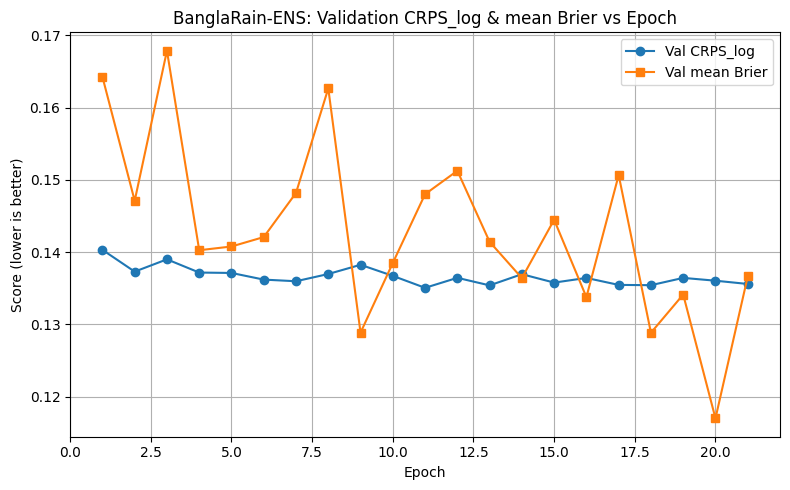

In [8]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class
#    - model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (SAME STRUCTURE AS TUNING/TRAINING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================

FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_no_missing/v1"
CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
# ckpt = torch.load(CKPT_PATH, map_location=device)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

hp = ckpt["hparams"]            # dict of best hyperparameters
state_dict = ckpt["state_dict"] # model weights

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")

# ---- 8.2 df_rain MUST BE LOADED HERE ----
# Example:
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")
# Make sure it is exactly the same dataset used in training.

# >>> UNCOMMENT AND SET YOUR PATH <<<
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")

# ---- 8.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# Train-only scaling (same as training)
X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

# Thresholds from TRAIN
thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

# Acc24 + thresholds
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))
thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
        device=device,
    )

print("\n========== TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

# --- NEW: Print MAE and RMSE ---
# These are lists (one value per forecast horizon). We print the mean.
maes = test_scores["MAE_mm_by_lead"]
rmses = test_scores["RMSE_mm_by_lead"]
print(f"\n[Deterministic] Mean MAE:  {np.nanmean(maes):.4f} mm")
print(f"[Deterministic] Mean RMSE: {np.nanmean(rmses):.4f} mm")
# Optional: print MAE & RMSE for specific lead times (e.g., 3h, 6h, 24h) if you want detail
print(f"(MAE per 3h step: {maes})")
print(f"(RMSE per 3h step: {rmses})")

# --- NEW: Print CSI, POD, FAR for a specific decision threshold ---
# You can change target_thr to 0.3 or 0.5 depending on what you want to report
target_thr = 0.5

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

# Helper function to safely print metrics if the threshold exists
def print_event_metrics(name, metrics, thr):
    print(f"\n[{name}] PR-AUC={metrics['pr_auc']:.4f}, ROC-AUC={metrics['roc_auc']:.4f}")
    if thr in metrics["by_thr"]:
        m = metrics["by_thr"][thr]
        print(f"   @Thr={thr}: CSI={m['CSI']:.4f}, POD={m['POD']:.4f}, FAR={m['FAR']:.4f}")
    else:
        print(f"   @Thr={thr}: Metrics not found (available: {list(metrics['by_thr'].keys())})")

print_event_metrics("Flash 3h", fm, target_thr)
print_event_metrics("Peak 24h", pm, target_thr)
print_event_metrics("Acc 24h",  am, target_thr)

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

# Compute mean Brier (flash/peak/acc) per epoch
log_df["mean_brier"] = log_df[["val_Brier_flash",
                               "val_Brier_peak",
                               "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
